# Lab 2: Some Deep Learning Basics from Scratch


In [55]:
## Basic libraries needed:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Some PyTorch stuff:
import torch
import torch.nn as nn


## Linear Regression/Gradient Descent from Scratch

**The goal here is for you to implement a version of gradient descent for simple linear regression yourself. Your methods need not be fancy, just functional.**

### Setup:

First consider the minimal linear regression

$$
\hat{y} = b + w_1 x_1,
$$

where $x_1$ is our only input feature, $w_1$ is the weight, and $b$ is the bias. To simplify our mathematical expressions, we can rewrite this as

$$
\hat{y} = \theta_0 x_0 + \theta_1 x_1
$$

where $x_0 = 1$, $\theta_0 = b$, and $\theta_1 = w_1$.

Let's make our error (or cost) function the mean square error (MSE):

$$
E = \frac{1}{n} \sum_{i=1}^n \left( \hat{y}^{(i)} - y^{(i)} \right)^2,
$$

or

$$
E = \frac{1}{n} \sum_{i=1}^n \left( \theta_0 + \theta_1 x_1^{(i)} - y^{(i)} \right)^2,
$$
where $n$ is the number of observations in the training dataset.

We need our gradient vector to run the gradient descend method. So, taking partial derivatives, we get

$$
\frac{\partial E}{\partial \theta_0} = \frac{2}{n} \sum_{i=1}^n \left( \theta_0 + \theta_1 x_1^{(i)} - y^{(i)} \right),
$$

$$
\frac{\partial E}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^n \left( \theta_0 + \theta_1 x_1^{(i)} - y^{(i)} \right) x_1^{(i)},
$$

We can re-write these as

$$
\frac{\partial E}{\partial \theta_0} = \frac{2}{n} \sum_{i=1}^n \left( \hat{y}^{(i)} - y^{(i)} \right),
$$

$$
\frac{\partial E}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^n \left( \hat{y}^{(i)} - y^{(i)} \right) x_1^{(i)},
$$

These expressions give us the change in the loss function with respect to either model parameter. To run gradient descent and iteratively update our estimates for $\theta_0$ and $\theta_1$, we simply use the following rule:

$$
\theta_{j}^{(\text{next})} = \theta_{j} - \eta \frac{\partial E (\theta_j)}{\partial \theta_j},
$$
where $\eta$ is our learning rate.


### Synthetic Data

Run the following cell to generate input ($x$) and output ($y$) data:

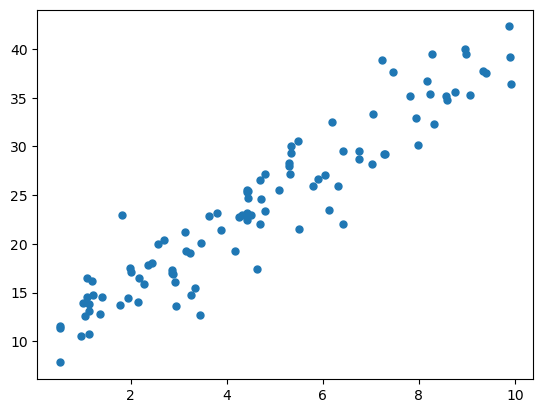

In [57]:
N = 100

#Random points between 0 and 10, sorted:
x = np.random.uniform(0, 10, N)
x.sort()

#Linear equation:
y = 3*x + 10 + np.random.normal(loc=0, scale=3, size=N)

#Plot our data:
plt.plot(x, y, 'o', markersize=5);

### Please implement the following:

Train a regression model on the given $x$ and $y$ in two ways:

1. (Full) batch gradient descent for linear regression with a single feature: Run the training loop for 1000 iterations.
2. Stochastic gradient descent for linear regression with a single feature: Each training loop, sample a single observation. Run 1000 training loops.

- In either case, use a fixed learning rate of $\eta = .01$, and use an initial guess of $\theta_0 = \theta_1 = 1$.

- Plot the evolution of the weight and bias, as below. Also, plot your model predictions against the training data, as also shown below:

<img src="lin-reg-full-batch.png">

<img src="lin-reg-SGD.png">

<br> <br>

Note that your stochastic gradient plots will vary slightly due to random chance.

**For this task, do not use any Scikit-Learn estimators or PyTorch functions!**

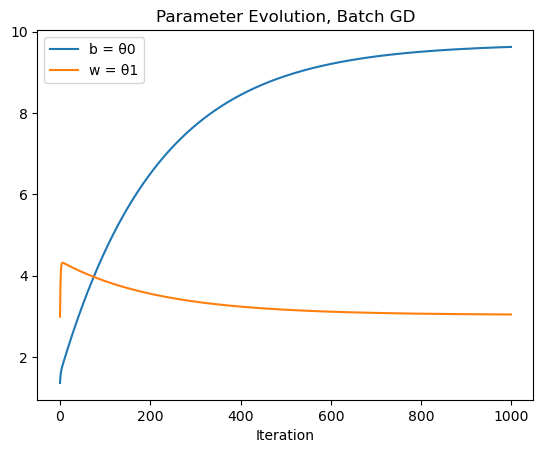

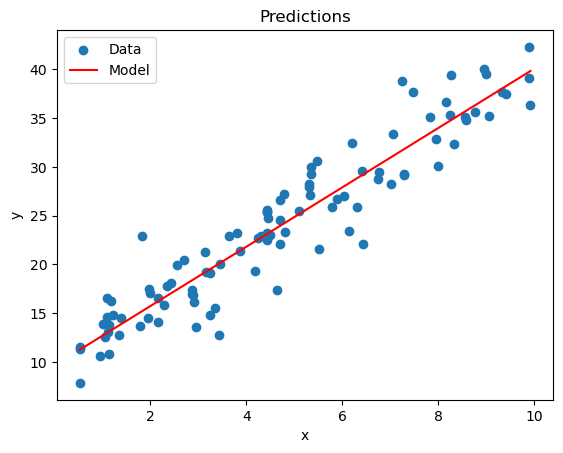

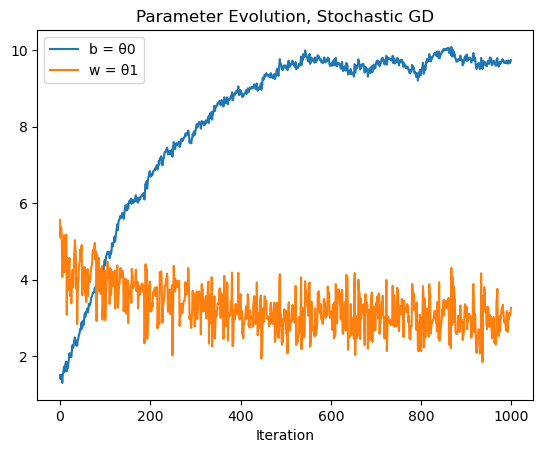

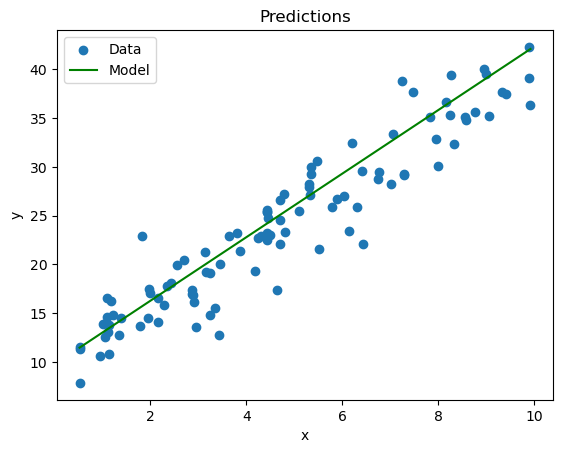

In [63]:
x.sort()

w = 1.0
b = 1.0
lr = 0.01
num_iters = 1000

w_list = []
b_list = []

for i in range(num_iters):
    
    y_hat = w * x + b
    error = y_hat - y
    

    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)
    
    w = w - lr * grad_w
    b = b - lr * grad_b
    
    w_list.append(w)
    b_list.append(b)


plt.plot(b_list, label="b = θ0")
plt.plot(w_list, label="w = θ1")
plt.legend()
plt.title("Parameter Evolution, Batch GD")
plt.xlabel("Iteration")
plt.show()


y_pred = w * x + b

plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, color='red', label="Model")
plt.legend()
plt.title("Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


w_sgd = 1.0
b_sgd = 1.0

w_list_sgd = []
b_list_sgd = []

for i in range(num_iters):
    
    idx = np.random.randint(0, len(x))
    
    x_i = x[idx]
    y_i = y[idx]
    
    y_hat = w_sgd * x_i + b_sgd
    error = y_hat - y_i
    
   
    grad_w = 2 * error * x_i
    grad_b = 2 * error
    
    w_sgd = w_sgd - lr * grad_w
    b_sgd = b_sgd - lr * grad_b
    
    w_list_sgd.append(w_sgd)
    b_list_sgd.append(b_sgd)


plt.plot(b_list_sgd, label="b = θ0")
plt.plot(w_list_sgd, label="w = θ1")
plt.legend()
plt.title("Parameter Evolution, Stochastic GD")
plt.xlabel("Iteration")
plt.show()


y_pred_sgd = w_sgd * x + b_sgd

plt.scatter(x, y, label="Data")
plt.plot(x, y_pred_sgd, color='green', label="Model")
plt.legend()
plt.title("Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Add Momentum + Nesterov Trick

Recall the basic momentum algorithm, in vector form:

$$
\mathbf{m} \leftarrow \beta \mathbf{m} - \eta \nabla E(\theta),
$$
$$
\theta \leftarrow \theta + \mathbf{m},
$$
where $\mathbf{m}$ is the momentum vector, and $\theta$ is our vector of model parameters.

Also recall that we can speed up the momentum algorithm by adding the Nesterov Trick: Update the momentum using not the gradient where you are, but where you will be! Mathematically:
$$
\mathbf{m} \leftarrow \beta \mathbf{m} - \eta \nabla E(\theta + \beta \mathbf{m}),
$$
$$
\theta \leftarrow \theta + \mathbf{m},
$$

**Extend your work above to implement momentum with the Nesterov Trick**

- Run (full) batch gradient descent with momentum for the same regression problem, with and without the Nesterov trick.

- You should observe that some momentum (e.g., $\beta = 0.9$) results in much faster convergence to the minimum. Using the Nesterov trick smoothes and may hasten this convergence.

- Plot the evolution of the weight and bias over 1,000 iterations of the method using a fixed learning rate of $\eta = .01$, an initial guess of $\theta_0 = \theta_1 = 1$, and an *exaggerated* momentum of $\beta = 0.99$. Plot this evolution with and without the Nesterov trick. Your results should resemble those below:

<img src="mom-and-mom-nesterov.png">

<br> <br>

**For this task, do not use any Scikit-Learn estimators or PyTorch functions!**

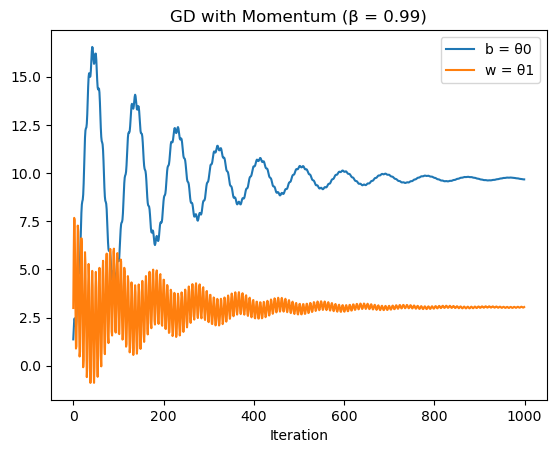

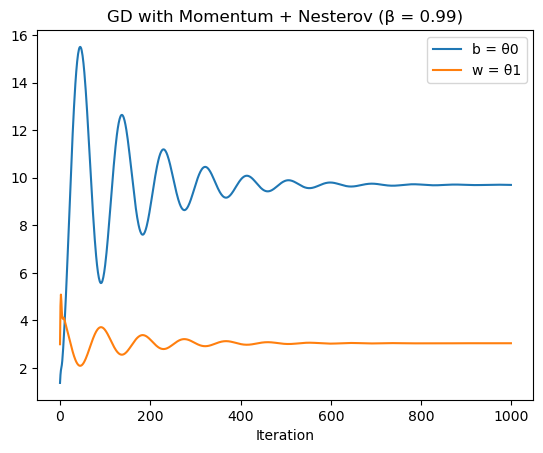

In [67]:
w_m = 1.0
b_m = 1.0

v_w = 0
v_b = 0

beta = 0.99
lr = 0.01
num_iters = 1000

w_list_m = []
b_list_m = []

for i in range(num_iters):
    
    y_hat = w_m * x + b_m
    error = y_hat - y
    
    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)
    
    # momentum update
    v_w = beta * v_w - lr * grad_w
    v_b = beta * v_b - lr * grad_b
    
    w_m = w_m + v_w
    b_m = b_m + v_b
    
    w_list_m.append(w_m)
    b_list_m.append(b_m)


w_n = 1.0
b_n = 1.0

v_w_n = 0
v_b_n = 0

w_list_n = []
b_list_n = []

for i in range(num_iters):
    
    # lookahead step
    w_look = w_n + beta * v_w_n
    b_look = b_n + beta * v_b_n
    
    y_hat = w_look * x + b_look
    error = y_hat - y
    
    grad_w = 2 * np.mean(error * x)
    grad_b = 2 * np.mean(error)
    
    # update momentum
    v_w_n = beta * v_w_n - lr * grad_w
    v_b_n = beta * v_b_n - lr * grad_b
    
    w_n = w_n + v_w_n
    b_n = b_n + v_b_n
    
    w_list_n.append(w_n)
    b_list_n.append(b_n)

plt.plot(b_list_m, label="b = θ0")
plt.plot(w_list_m, label="w = θ1")
plt.legend()
plt.title("GD with Momentum (β = 0.99)")
plt.xlabel("Iteration")
plt.show()

plt.plot(b_list_n, label="b = θ0")
plt.plot(w_list_n, label="w = θ1")
plt.legend()
plt.title("GD with Momentum + Nesterov (β = 0.99)")
plt.xlabel("Iteration")
plt.show()


## Implement Logistic Regression "Directly" Using PyTorch AutoGrad + Optimizer

- Let's generate some synthetic data using a logistic regression model
- And then fit a logistic regression model using PyTorch AutoGrad, BCECrossEntropy Loss Function, and SGD Optimizer. Do not use `nn.Linear` or `nn.Module` for this task.

Run the following cells to generate our synthetic data as PyTorch tensors:

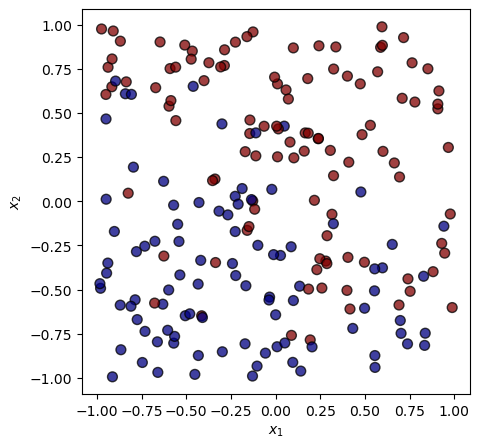

In [17]:
#Some synthetic data
N = 200

#Two random features:
np.random.seed(2)
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)

#Underlying logit:
y_logit = 2*x1 + 4*x2 + .5

#Probability of being in particular class:
p = 1 / (1 + np.exp(-y_logit))

#Randomly determine class based on probabilities:
rand = np.random.uniform(0,1,N)
y = (rand < p).astype(np.float32)



#Plot our data:
fig, ax1 = plt.subplots(1, 1, figsize=(5,5)) #, dpi=300)

ax1.scatter(x1, x2, c=y, s=50, cmap='jet', edgecolor='black', alpha=.75)#, label=['a','b']);

ax1.set_xlabel('$x_1$', fontweight='bold')
ax1.set_ylabel('$x_2$', fontweight='bold');
#ax1.legend()

In [19]:
## Convert to PyTorch tensors:
x1 = torch.tensor(x1, dtype=torch.float32).unsqueeze(dim=1)
x2 = torch.tensor(x2, dtype=torch.float32).unsqueeze(dim=1)

y = torch.tensor(y, dtype=torch.float32).unsqueeze(dim=1)

In [21]:
## Input as matrix tensor:
X = torch.hstack((x1,x2))


### Setup Model

Now, create, as PyTorch tensors, an appropriate weight vector and bias, where initial weights are drawn from a standard normal distribution and the bias is set to $0$. Be sure you set `requires_grad = True` when you construct these tensors.

Write a function that predicts (logistic regression) model output (as class $1$ probability, not a binary), given these parameters and an input data matrix, $X$:

```
def run_model(w, b, X):
    ...
```

Note that `run_model` should apply a sigmoid activation function before returning the output.

In [81]:
w = torch.randn((2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def run_model(w, b, X):
    z = X @ w + b
    y_hat = torch.sigmoid(z)
y_hat = torch.clamp(y_hat, 1e-7, 1 - 1e-7)

In [33]:
##Function for the decision boundaries:
######

#Colormap we'll use:

from matplotlib.colors import ListedColormap
my_cmap = (ListedColormap(["blue", "red"]))

##Let's make a function to plot our decision surface:
######

def plot_contour(X, ax):
    #Range for contour:
    x1 = X[:,0].min(); x2 = X[:,0].max()*1.025
    y1 = X[:,1].min(); y2 = X[:,1].max()*1.025
        
    #Points for contour
    X1, Y1 = np.meshgrid(np.linspace(x1, x2, 200),
                         np.linspace(y1, y2, 200))

    #Get as Nx2:
    XY_ravel = np.c_[X1.ravel(), Y1.ravel()]


    #Get the class:
    #Z = clf.predict_proba(XY_ravel)[:,0]
    Z = run_model(w, b, torch.tensor(XY_ravel, dtype=torch.float32))
    
    #Reshape back:
    Z = Z.reshape(X1.shape)


    #Plot:
    ax.contourf(X1, Y1, Z.detach().numpy(), 10, alpha=.65, cmap='jet') #my_cmap)
    #ax.contourf(X1, Y1, Z.detach().numpy(), 10, alpha=.5, cmap=my_cmap)

    ax.contour(X1, Y1, Z.detach().numpy(), 1, alpha=1, linewidths=2, colors='black')


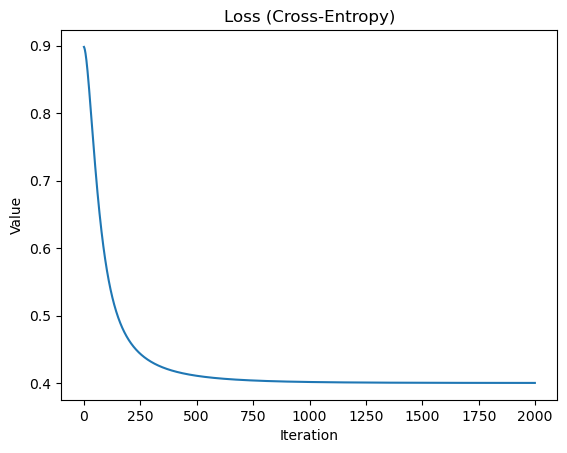

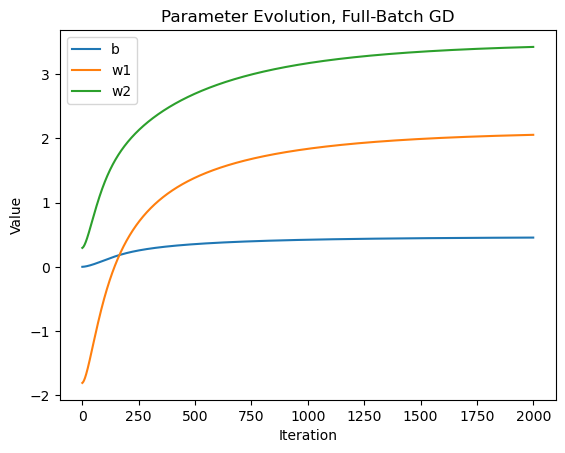

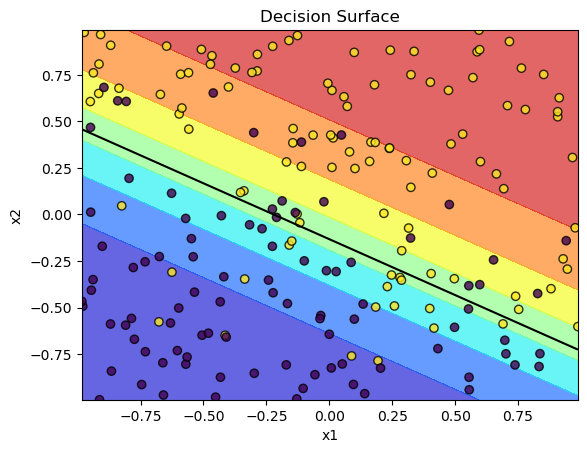

In [85]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

N = 200
np.random.seed(2)

x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)

y_logit = 2*x1 + 4*x2 + 0.5
p = 1 / (1 + np.exp(-y_logit))

rand = np.random.uniform(0,1,N)
y = (rand < p).astype(np.float32)


x1 = torch.tensor(x1, dtype=torch.float32).unsqueeze(1)
x2 = torch.tensor(x2, dtype=torch.float32).unsqueeze(1)
y  = torch.tensor(y, dtype=torch.float32).view(-1,1)

X = torch.hstack((x1, x2))


w = torch.randn((2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def run_model(w, b, X):
    z = X @ w + b
    y_hat = torch.sigmoid(z)
    return y_hat


loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.SGD([w, b], lr=0.005, momentum=0.95, nesterov=True)


num_iters = 2000
loss_list = []
w_list = []
b_list = []

for i in range(num_iters):
    y_hat = run_model(w, b, X)
    loss = loss_fn(y_hat, y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_list.append(loss.item())
    w_list.append(w.detach().clone())
    b_list.append(b.detach().clone())


plt.plot(loss_list)
plt.title("Loss (Cross-Entropy)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.show()


w1_vals = [w[0].item() for w in w_list]
w2_vals = [w[1].item() for w in w_list]
b_vals  = [b.item() for b in b_list]

plt.plot(b_vals, label="b")
plt.plot(w1_vals, label="w1")
plt.plot(w2_vals, label="w2")
plt.legend()
plt.title("Parameter Evolution, Full-Batch GD")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.show()


my_cmap = ListedColormap(["blue", "red"])

def plot_contour(X_np, ax):
    x1_min, x1_max = X_np[:,0].min(), X_np[:,0].max()
    x2_min, x2_max = X_np[:,1].min(), X_np[:,1].max()
    
    X1, X2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                         np.linspace(x2_min, x2_max, 200))
    
    grid = np.c_[X1.ravel(), X2.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)
    
    Z = run_model(w, b, grid_tensor).detach().numpy()
    Z = Z.reshape(X1.shape)
    
    ax.contourf(X1, X2, Z, alpha=0.6, cmap='jet')
    ax.contour(X1, X2, Z, levels=[0.5], colors='black')


fig, ax = plt.subplots()

plot_contour(X.detach().numpy(), ax)

ax.scatter(X[:,0].detach().numpy(),
           X[:,1].detach().numpy(),
           c=y.detach().numpy().ravel(),
           edgecolor='black',
           alpha=0.8)

plt.title("Decision Surface")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

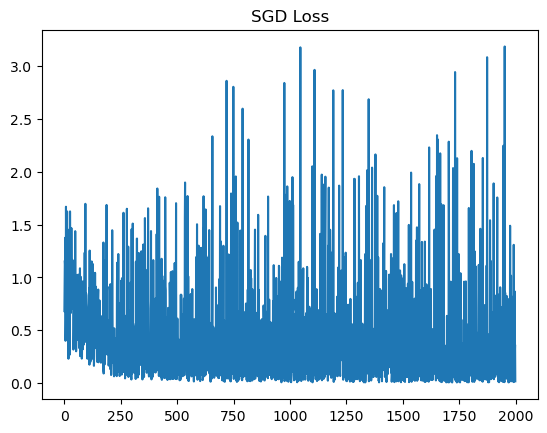

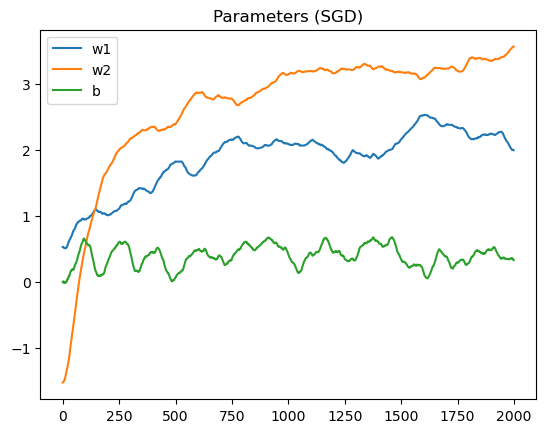

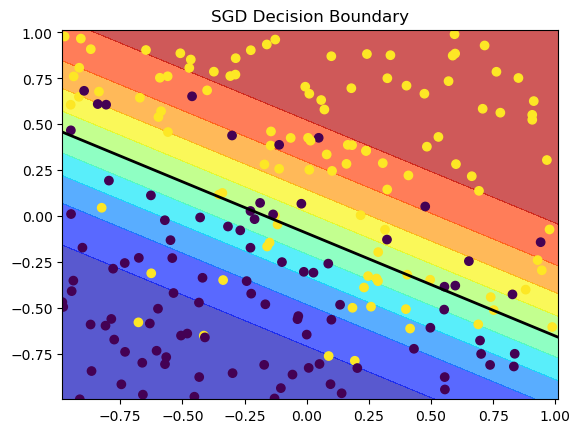

In [47]:
w = torch.randn((2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.005, momentum=0.95, nesterov=True)

loss_list_sgd = []
w_list_sgd = []
b_list_sgd = []

for i in range(num_iters):
    
    idx = torch.randint(0, X.shape[0], (1,))
    
    X_i = X[idx]
    y_i = y[idx]
    
    y_hat = run_model(w, b, X_i)
    loss = loss_fn(y_hat, y_i)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_list_sgd.append(loss.item())
    w_list_sgd.append(w.detach().clone())
    b_list_sgd.append(b.detach().clone())


plt.plot(loss_list_sgd)
plt.title("SGD Loss")
plt.show()

w_vals_sgd = [w[0].item() for w in w_list_sgd]
w2_vals_sgd = [w[1].item() for w in w_list_sgd]
b_vals_sgd = [b.item() for b in b_list_sgd]

plt.plot(w_vals_sgd, label="w1")
plt.plot(w2_vals_sgd, label="w2")
plt.plot(b_vals_sgd, label="b")
plt.legend()
plt.title("Parameters (SGD)")
plt.show()

fig, ax = plt.subplots()
plot_contour(X.detach().numpy(), ax)

ax.scatter(X[:,0].detach().numpy(),
           X[:,1].detach().numpy(),
           c=y.detach().numpy())

plt.title("SGD Decision Boundary")
plt.show()


<br> <br>
For contour plot, you can use the following `contour_plot()` function (as we did in class).

<br>

In [49]:
##Function for the decision boundaries:
######

#Colormap we'll use:

from matplotlib.colors import ListedColormap
my_cmap = (ListedColormap(["blue", "red"]))

##Let's make a function to plot our decision surface:
######

def plot_contour(X, ax):
    #Range for contour:
    x1 = X[:,0].min(); x2 = X[:,0].max()*1.025
    y1 = X[:,1].min(); y2 = X[:,1].max()*1.025
        
    #Points for contour
    X1, Y1 = np.meshgrid(np.linspace(x1, x2, 200),
                         np.linspace(y1, y2, 200))

    #Get as Nx2:
    XY_ravel = np.c_[X1.ravel(), Y1.ravel()]


    #Get the class:
    #Z = clf.predict_proba(XY_ravel)[:,0]
    Z = run_model(w, b, torch.tensor(XY_ravel, dtype=torch.float32))
    
    #Reshape back:
    Z = Z.reshape(X1.shape)


    #Plot:
    ax.contourf(X1, Y1, Z.detach().numpy(), 10, alpha=.65, cmap='jet') #my_cmap)
    #ax.contourf(X1, Y1, Z.detach().numpy(), 10, alpha=.5, cmap=my_cmap)

    ax.contour(X1, Y1, Z.detach().numpy(), 1, alpha=1, linewidths=2, colors='black')


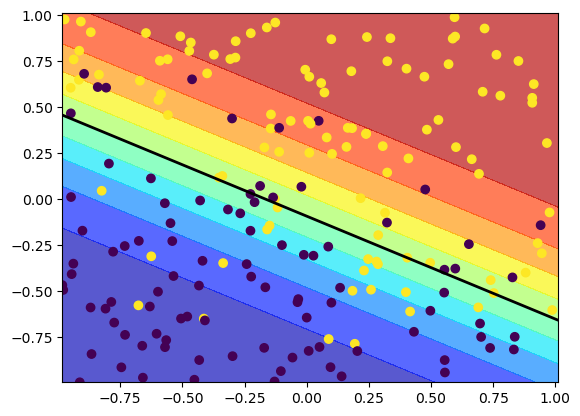

In [51]:
fig, ax = plt.subplots()

plot_contour(X.detach().numpy(), ax)

ax.scatter(X[:,0].detach().numpy(),
           X[:,1].detach().numpy(),
           c=y.detach().numpy())

plt.show()